## Visualize dataset

In [4]:
# fetching dataset
from dataset import LITSDataset, LITSImageTransform
from visualize import *

import torch
dataset = LITSDataset(
    images_dir="./dataset/nii",
    masks_dir="./dataset/nii",
    slice_axis=2,
    transform=LITSImageTransform(),
    test_size=0.05,
    split="all"
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

for sample in dataloader:
    print(sample.keys())
    break

len(dataset),len(dataloader), dataset, dataloader


Loading slice mapping from cache...
dict_keys(['image', 'mask', 'image_path', 'slice_idx'])


(11032,
 2758,
 <torch.utils.data.dataloader.DataLoader at 0x7ff54c44b2b0>)

In [6]:
dataset.set_split("test")
print("length of test split", len(dataset))

dataset.set_split("train")
print("length of train split", len(dataset))


length of test split 552
length of train split 10480


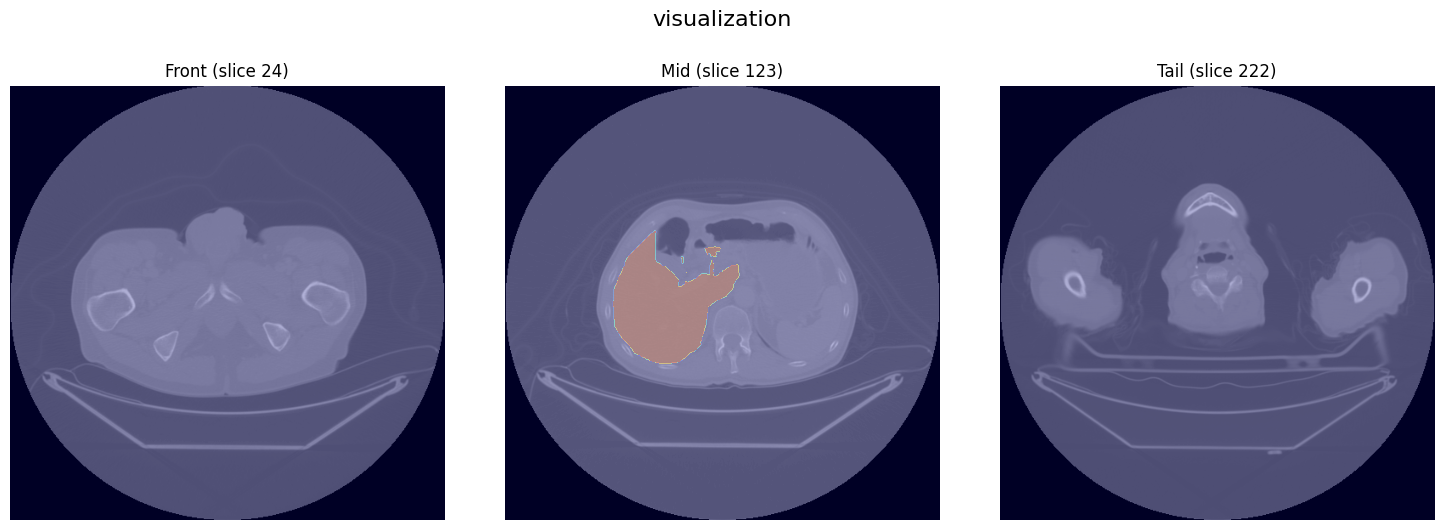

In [5]:
import os

# Load and visualize both the image and mask NIfTI files
num = 22
image_path = f"./dataset/nii/volume-{num}.nii"
mask_path = f"./dataset/nii/segmentation-{num}.nii"

assert os.path.exists(image_path)
assert os.path.exists(mask_path)

# Basic static visualization
_ = visualize_nii(
    nii_path=image_path,
    mask_path=mask_path, 
    cmap='gray',
    mask_alpha=0.3  
)


In [7]:
import numpy as np
# finding average mean of each sample, to find percentage of unsegmented samples
# this was done, when trying prior to creation of the create_slice_mapping in dataset. 
# since after training it didn't segment due to over 50% of mask empty
# THIS TAKES A LONG TIME TO RUN. SKIP IT!
averages = []
non_zeros = []
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)
VAL=0.2 # now can test with 
total = 0
for i, sample in enumerate(dataloader):
    if i > 15:
        break
    x = sample["mask"]
    avgs = x.view(x.size(0), -1).float().mean(1, keepdim=True)
    total += len(avgs)
    zeros = [np.count_nonzero(x[i]) for i in range(x.size(0))]
    non_zeros += [zero for zero in zeros if zero > 0]
    averages += [i.item() for i in avgs if i.item() > VAL]

print(len(averages), len(non_zeros), total)
print(f"average of masked samples with avg > {VAL} out of {total}: {len(averages)*100/total:.3f}%, non zeros: {len(non_zeros)*100/total:.3f}%")

0 64 64
average of masked samples with avg > 0.2 out of 64: 0.000%, non zeros: 100.000%


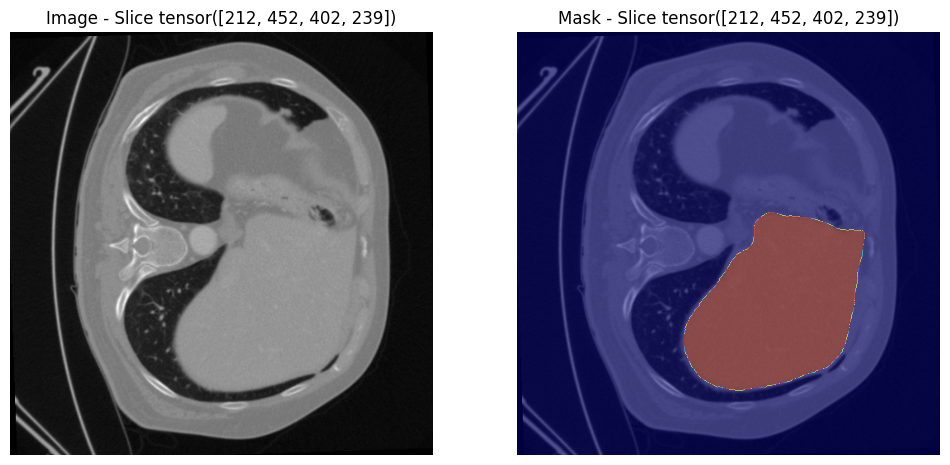

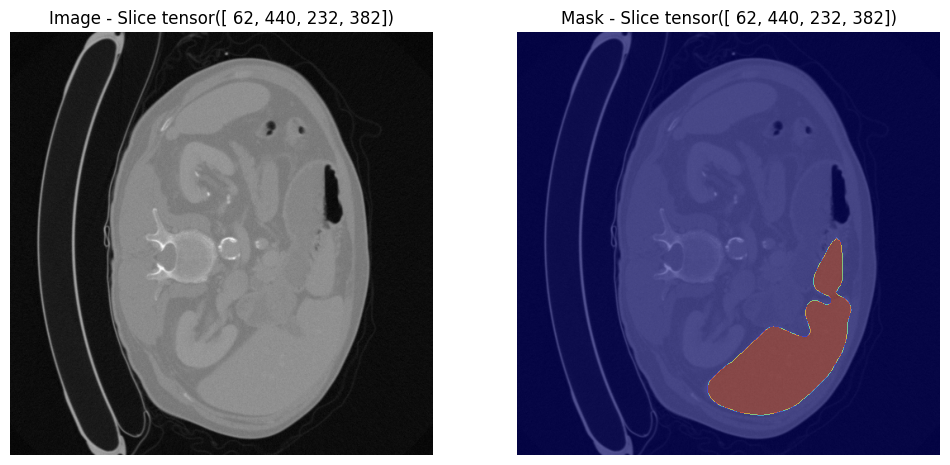

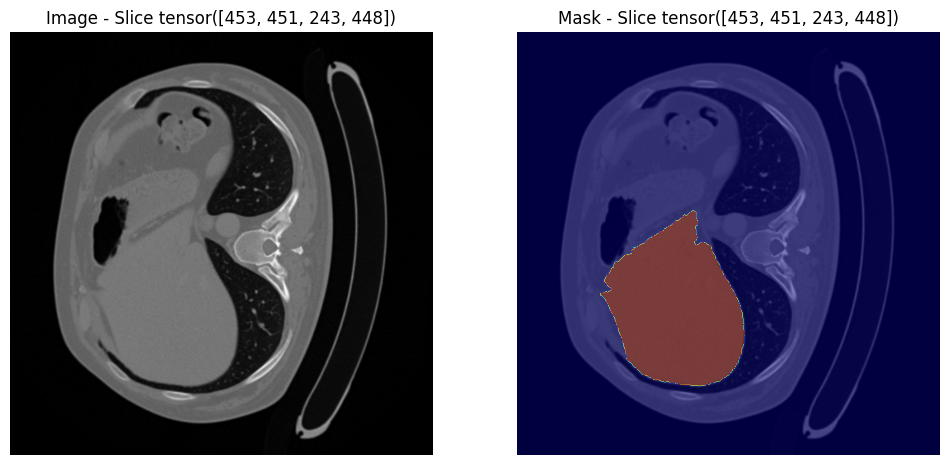

In [8]:
num_samples = 3
for i, sample in enumerate(dataloader):
    if i > num_samples - 1:
        break
    image = sample['image'][0] # fetch only first batch
    mask = sample['mask'][0]

    visualize_sample(sample)
# _ = visualize_from_loader(dataloader, num_samples=3)

## Train model

In [9]:
## Train model
!python3 train.py -d=cuda:0 --use_small --batch_size=8 --epoch=5 


 Namespace(build_path='build', device='cuda:0', epochs=5, batch_size=8, use_small=True) 
 --------
Loading slice mapping from cache...
length of dataset =  10480 
 --------
Testing small model
Downloading: "https://download.pytorch.org/models/lraspp_mobilenet_v3_large-d234d4ea.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/lraspp_mobilenet_v3_large-d234d4ea.pth
100%|███████████████████████████████████████| 12.5M/12.5M [00:00<00:00, 142MB/s]
Traceback (most recent call last):
  File "/teamspace/studios/this_studio/another/ileri_sayisal/train.py", line 112, in <module>
    model = get_model_small(3, save_path)
  File "/teamspace/studios/this_studio/another/ileri_sayisal/train.py", line 12, in get_model_small
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
TypeError: 'LRASPPHead' object does not support item assignment


In [ ]:
!python3 test.py -d=cuda:0 --batch_size=8 --use_small -w=./build/f_large_model.pth 

usage: test.py [-h] [-d DEVICE] [-b BATCH_SIZE] -w WEIGHT_PATH
test.py: error: unrecognized arguments: --use_small


## Make inference

In [3]:
import os
from train import get_model_large
save_path="./build/f_large_model.pth"
device = "cuda:0" if torch.cuda.is_available() else "cpu"

assert os.path.exists(save_path)

model = get_model_large(3, save_path, device=device) 



Loading weights from local directory: ./build/f_large_model.pth


Actual


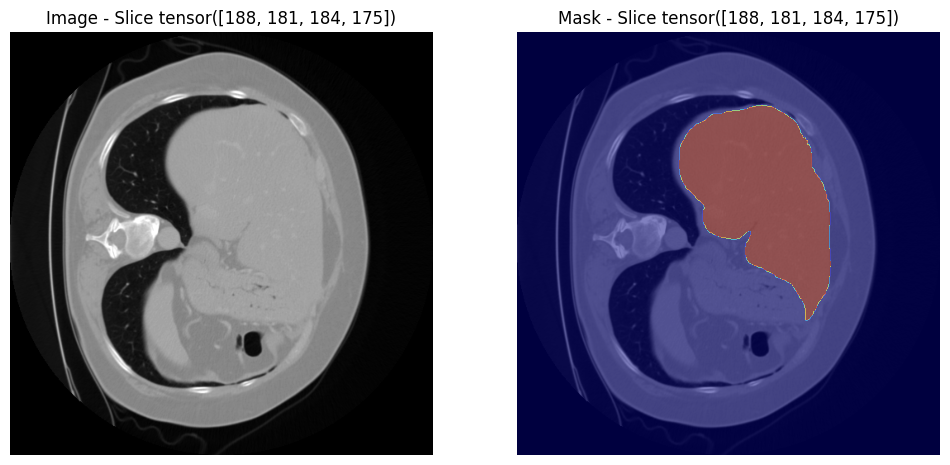

torch.Size([4, 512, 512]) tensor([0, 1]) torch.int64
Predictions


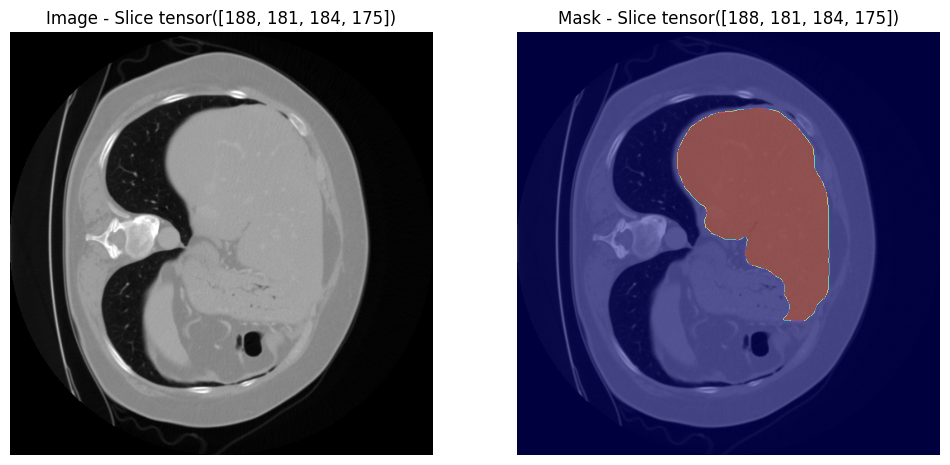

In [35]:
from torch.nn import functional as F
for sample in dataloader:
    print("Actual")
    visualize_sample(sample)
    images = sample['image'].to(device)  # Shape: [B, 1, 512, 512]
    masks = sample['mask'].to(device)    # Shape: [B, 512, 512]

        # Repeat the channels for a 3-channel input
    images = images.repeat(1, 3, 1, 1)
    # Forward pass
    outputs = model(images)["out"]
    outputs_prob = F.softmax(outputs, dim=1)
    preds = torch.argmax(outputs_prob, dim=1)  # Get predicted class for each pixel

    pred_sample = {
        'image': sample['image'],
        'slice_idx': sample['slice_idx'],
        'mask': preds
    }
        # pred_sample = sample.copy()
        # pred_sample['mask'] = preds
    print("Predictions")
    visualize_sample(pred_sample)
    break

## Inference with a video

In [39]:
# !sudo apt install python3-opencv
# !pip install opencv-python moviepy
from IPython.display import Video, display
from matplotlib import pyplot as plt
from torchvision.models.segmentation import deeplabv3_resnet101
import cv2
import os
from PIL import Image
import numpy as np
from torchvision import transforms
from train import get_model_large
import torch



input_video_path = "/teamspace/studios/this_studio/ileri_sayisal/video_2025-01-13_00-20-03.mp4"
output_video_path = "output_segmented_video.mp4"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert os.path.exists(input_video_path)

# Define preprocessing transformation
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((512, 512)),  # Resize to match model input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define postprocessing function to convert output to a mask
def postprocess(output, original_size):
    output = torch.argmax(output, dim=0).cpu().numpy()
    output = cv2.resize(output, original_size, interpolation=cv2.INTER_NEAREST)
    return output

# model = deeplabv3_resnet101(pretrained=True)
# model = model.to(device)
# model.eval()

save_path="./build/f_large_model.pth"
device = "cuda:0" if torch.cuda.is_available() else "cpu"

assert os.path.exists(save_path)

model = get_model_large(3, save_path, device=device) 


# Create a directory for temporary frame storage
os.makedirs("temp_frames", exist_ok=True)

def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_size = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_path = f"temp_frames/frame_{count:04d}.png"
        cv2.imwrite(frame_path, frame)
        count += 1
    
    cap.release()
    return frame_count, fps, frame_size

def segment_frames(frame_count, frame_size, min_area=10000):
    segmented_frames = []
    
    for i in range(frame_count):
        frame_path = f"temp_frames/frame_{i:04d}.png"
        frame = cv2.imread(frame_path)
        original_size = frame.shape[:2]
        input_tensor = preprocess(frame).unsqueeze(0).to(device)
        input_tensor = input_tensor.repeat(4, 1, 1, 1)
        with torch.no_grad():
            # NOTE: still dont know how to sort it out but it needs 4 batches to train., so
            output = model(input_tensor)["out"].squeeze(0)
        
        # using only the first batch
        mask = postprocess(output[0], original_size[::-1])
        color_mask = cv2.applyColorMap((mask * 255).astype(np.uint8), cv2.COLORMAP_BONE)
        overlay = cv2.addWeighted(frame, 0.5, color_mask, 0.5, 0)

        # Add bounding boxes (excluding small segments)
        mask_binary = (mask > 0.90).astype(np.uint8)  # Threshold mask to binary
        contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > min_area:  # Only process large enough segments
                x, y, w, h = cv2.boundingRect(contour)
                cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw green boxes
        
        segmented_frames.append(overlay)

    return segmented_frames

def display_segmented_frames(segmented_frames):
    #NOTE: not working!! don't know why?!
    for frame in segmented_frames:
        # Display the frame in a window named 'Segmented Frame'
        cv2.imshow('Segmented Frame', frame)
        
        # Wait for 1 ms and check if the user pressed the 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Close all OpenCV windows
    cv2.destroyAllWindows()

# Save segmented frames as a video
def save_segmented_video(segmented_frames, output_path, fps, frame_size):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, frame_size)
    
    for frame in segmented_frames:
        out.write(frame)
    
    out.release()

print("extracting frames")
frame_count, fps, frame_size = extract_frames(input_video_path)
print("segmenting frames")
segmented_frames = segment_frames(frame_count, frame_size)
print("saving video")
save_segmented_video(segmented_frames, output_video_path, fps, frame_size)
# display_segmented_frames(segmented_frames)
# Cleanup temporary files
for file in os.listdir("temp_frames"):
    os.remove(os.path.join("temp_frames", file))
os.rmdir("temp_frames")

# Display videos in Jupyter
# print("Original Video:")
# display(Video(input_video_path, embed=True, width=400, height=300))
# display(Video(output_video_path, embed=True, width=400, height=300))


/home/amarjay/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


AssertionError: 

In [2]:
from train import get_model_small, get_model_large
# Define a wrapper to extract only the 'out' from the model
class DeeplabWrapper(torch.nn.Module):
    def __init__(self, deeplab_model):
        super().__init__()
        self.deeplab_model = deeplab_model

    def forward(self, x):
        return self.deeplab_model(x)["out"]

model = get_model_large(3, "./f_large_model.pth")

# QUANTIZE THE MODEL DYNAMICALLY
# This will quantize the linear layers of the model to reduce size and improve inference speed
# model.backbone = torch.quantization.quantize_dynamic(
#     model.backbone, {torch.nn.Linear}, dtype=torch.qint8
# )


# Load pretrained model and wrap it
wrapped_model = DeeplabWrapper(model)
wrapped_model.eval()

# Create dummy input
dummy_input = torch.randn(1, 3, 512, 512)

# Export to ONNX
onnx_path = "f_large_model.onnx"
onnx_program = torch.onnx.export(wrapped_model, dummy_input, dynamo=True)

onnx_program.optimize()

onnx_program.save(onnx_path)

print(f"ONNX model exported to {onnx_path}")


Loading weights from local directory: ./f_large_model.pth
[torch.onnx] Obtain model graph for `DeeplabWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeeplabWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model exported to f_large_model.onnx


In [7]:
import onnxruntime
model = get_model_large(3, "./f_large_model.pth")
cap = cv2.VideoCapture("/home/amarjay/Desktop/code/ileri_sayisal/video_2025-01-13_00-20-03.mp4")  # Use 0 for webcam

ret, frame = cap.read()
if not ret:
    raise ValueError("Failed to read frame from video. Check the video path or camera.")

img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
img = np.transpose(img, (2, 0, 1))  # HWC to CHW
img = np.expand_dims(img, axis=0)  # Add batch dim
input_tensor = torch.rand(1, 3, 512, 512)
# input_tensor = img
print(f"Input tensor shape: {input_tensor.shape} {frame.shape}")
wrapped_out = model(input_tensor)
wrapped_out
# print(f"Input tensor shape: {input_tensor.shape}")
# # onnx_inputs = [tensor.numpy(force=True) for tensor in example_inputs]
# # print(f"Input length: {len(onnx_inputs)}")
# # print(f"Sample input: {onnx_inputs}")

# ort_session = onnxruntime.InferenceSession(
#     "./f_large_model.onnx", providers=["CPUExecutionProvider"]
# )

# ort_session.get_inputs()[0].name

# onnxruntime_input = {ort_session.get_inputs()[0].name: input_tensor}

# # ONNX Runtime returns a list of outputs
# onnxruntime_outputs = ort_session.run(None, onnxruntime_input)[0]

# # Convert the output to a mask
# onnxruntime_outputs.shape

Loading weights from local directory: ./f_large_model.pth
Input tensor shape: torch.Size([1, 3, 512, 512]) (800, 1280, 3)


: 

In [ ]:
import cv2
import numpy as np
import onnxruntime as ort

# ONNX model path
onnx_path = "q_large_model.onnx"

# Initialize ONNX Runtime session
session = ort.InferenceSession(onnx_path)
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

# Preprocessing (no torch)
def preprocess(frame):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (512, 256))
    center = (img.shape[1]//2, img.shape[0]//2)
    size = 224
    cropped = img[
        center[1] - size//2:center[1] + size//2,
        center[0] - size//2:center[0] + size//2
    ]
    img = cropped.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std
    img = np.transpose(img, (2, 0, 1))  # HWC to CHW
    img = np.expand_dims(img, axis=0)  # Add batch dim
    img = img.astype(np.float32)
    return img


num_classes = 3
palette = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)

def decode_segmentation(mask):
    return palette[mask]

# Video input: 0 for webcam or a video path
cap = cv2.VideoCapture("/home/amarjay/Desktop/code/ileri_sayisal/video_2025-01-13_00-20-03.mp4")  # Use 0 for webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    input_tensor = preprocess(frame)
    output = session.run([output_name], {input_name: input_tensor})[0]
    seg = np.argmax(output[0], axis=0)  # Shape: (H, W)
    seg_color = palette[seg]
    seg_color = cv2.resize(seg_color, (frame.shape[1], frame.shape[0]))

    overlay = cv2.addWeighted(frame, 0.5, seg_color, 0.5, 0)

    cv2.imshow("Deeplabv3 Segmentation", overlay)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


KeyboardInterrupt: 